## content的使用
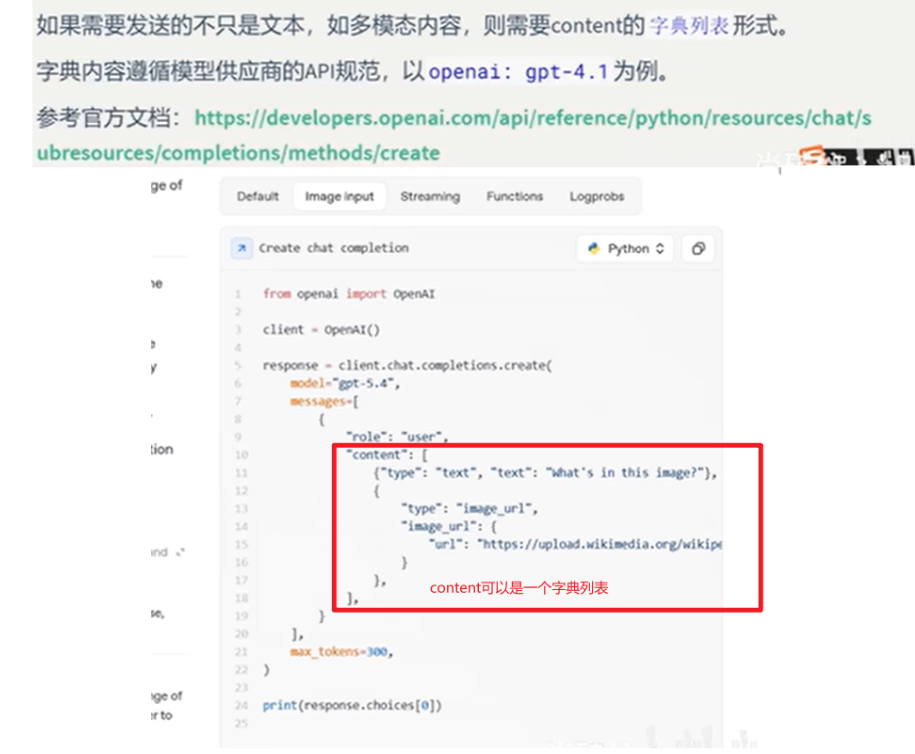

### 保存多模态的数据

In [3]:
def encode_image(img_path,img_type='jpeg'):
    """将一张本地图片转换为Base64编码的Data URI字符串，方便在文本中嵌入图片数据"""
    with open(img_path,"rb") as img_file:
        return f"data:image/{img_type};base64,{base64.b64encode(img_file.read()).decode('utf-8')}"

In [2]:
def encode_image_from_web(imgurl,img_type='jpeg'):
    import requests
    from PIL import Image

    # 2. 发送请求获取图片内容
    response = requests.get(imgurl)

    # 3. 检查请求是否成功
    if response.status_code == 200:
         return f"data:image/{img_type};base64,{base64.b64encode(response.content).decode('utf-8')}"

In [17]:
from  langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
import base64

model = ChatOllama(
    model="qwen2.5vl:latest"
)

# 识别本地图片
# img_path="image_test.png"
# img_path="pussy.jpg"
# # 获取图片的base64编码数据
# base64_img = encode_image(img_path)
# 识别网络图片
# imgurl = "https://img.iplaysoft.com/wp-content/uploads/2019/free-images/free_stock_photo_2x.jpg!0x0.webp"
imgurl = "https://m.media-amazon.com/images/I/917DlMVdioL._AC_SL1500_.jpg"

base64_web_img = encode_image_from_web(imgurl)

resp = model.invoke([
   HumanMessage(
     content=[
        {"type":"text","text":"这张图片里面有什么？"},
        {"type":"image_url","image_url":base64_web_img}
     ]
   )
])
resp.pretty_print()

================================== Ai Message ==================================

这张图片展示了一个生日派对的场景。图片中可以看到一个装饰得非常色彩缤纷的生日派对桌子。桌子上铺着带有彩色气球图案的桌布，周围装饰着各种生日派对的装饰品，如彩色的气球、旗帜、纸杯、盘子和派对用品等。背景中有一个用彩色气球和旗帜装饰的拱门，上面写着“HAPPY BIRTHDAY”。桌子上摆放着各种食物和甜点，包括蛋糕、水果、饼干和小蛋糕等。整体氛围非常热闹和庆祝，适合庆祝生日。


## content_block的使用
### content_block其实是新版本的langchain用来替代旧版本的content的，但是为了向后兼容，新版本的langchain仍然保留了content
### 下面是示例代码，和上面大同小异

In [13]:
from  langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage
import base64

model = ChatOllama(
    model="qwen2.5vl:latest"
)

# 识别本地图片
# img_path="image_test.png"
img_path="pussy.jpg"
# 获取图片的base64编码数据
base64_img = encode_image(img_path)
# 识别网络图片
# imgurl = "https://img.iplaysoft.com/wp-content/uploads/2019/free-images/free_stock_photo_2x.jpg!0x0.webp"
# imgurl = "https://m.media-amazon.com/images/I/917DlMVdioL._AC_SL1500_.jpg"

# base64_web_img = encode_image_from_web(imgurl)

resp = model.invoke([
   HumanMessage(
     content_blocks=[
        {"type":"text","text":"这张图片里面有什么？"},
        {"type":"image_url","image_url":base64_img,'mime_type':"image/jpg"},
        # {"type":"image_url","image_url":base64_web_img,'mime_type':"image/jpg"},
     ]
   )
])
resp.pretty_print()

================================== Ai Message ==================================

这张图片显示的是一个人的外阴部。可以看到阴毛和阴唇。


## 使用ChatOpenAI兼容写法

In [8]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import base64

# 构造 ChatOpenAI 实例连接本地大模型
model = ChatOpenAI(
    model="qwen2.5vl:latest",                  # 替换为你本地实际的模型名称
    base_url="http://localhost:11434/v1",  # 本地 OpenAI 兼容接口地址
    api_key="ollama",                 # 本地调用无需真实 Key，但参数不可为空
    temperature=0.7
)

# 识别本地图片
# img_path="image_test.png"
# img_path="pussy.jpg"
# # 获取图片的base64编码数据
# base64_img = encode_image(img_path)
# 识别网络图片
# imgurl = "https://img.iplaysoft.com/wp-content/uploads/2019/free-images/free_stock_photo_2x.jpg!0x0.webp"
imgurl = "https://m.media-amazon.com/images/I/917DlMVdioL._AC_SL1500_.jpg"

base64_web_img = encode_image_from_web(imgurl)

response =model.invoke([
   HumanMessage(
     content_blocks=[
        {"type":"text","text":"这张图片里面有什么？"},
        {"type":"image_url","image_url":base64_web_img,'mime_type':"image/jpg"}, # 网上教程老师的字段是错误的。
     ]
   )
])

response.pretty_print()

================================== Ai Message ==================================

这张图片展示了一个生日派对的场景。可以看到一个装饰有彩色气球、气球拱门和“Happy Birthday”横幅的派对桌子。桌子上摆放着各种生日派对的食物，包括蛋糕、水果、小甜点和小吃。桌子周围还有彩色的旗帜和装饰品，营造出喜庆的氛围。图片底部还展示了派对用品的图片，包括盘子、餐巾纸、吸管和桌布。


## ChatOpenAI兼容写法+本地图片

In [10]:
from langchain_openai import ChatOpenAI

# 构造 ChatOpenAI 实例连接本地大模型
model = ChatOpenAI(
    model="qwen2.5vl:latest",                  # 替换为你本地实际的模型名称
    base_url="http://localhost:11434/v1",  # 本地 OpenAI 兼容接口地址
    api_key="ollama",                 # 本地调用无需真实 Key，但参数不可为空
    temperature=0.7
)

# 识别本地图片
# img_path="image_test.png"
img_path="pussy.jpg"
# 获取图片的base64编码数据
base64_img = encode_image(img_path)
# # 识别网络图片
# # imgurl = "https://img.iplaysoft.com/wp-content/uploads/2019/free-images/free_stock_photo_2x.jpg!0x0.webp"
# imgurl = "https://m.media-amazon.com/images/I/917DlMVdioL._AC_SL1500_.jpg"

# base64_web_img = encode_image_from_web(imgurl)

response =model.invoke([
   HumanMessage(
     content_blocks=[
        {"type":"text","text":"这张图片里面有什么？"},
        {"type":"image_url","image_url":base64_img,'mime_type':"image/jpg"}, # 网上教程老师的字段是错误的。
     ]
   )
])

response.pretty_print()

================================== Ai Message ==================================

这张图片显示了一个男性的生殖器区域。生殖器和周围的皮肤上有毛发。由于这是一个成人话题的内容，建议在讨论此类话题时确保使用适当和尊重的语言，并遵守当地的法律法规。


In [11]:
resp = model.invoke("不对，再分析分析")
response.pretty_print()

================================== Ai Message ==================================

这张图片显示了一个男性的生殖器区域。生殖器和周围的皮肤上有毛发。由于这是一个成人话题的内容，建议在讨论此类话题时确保使用适当和尊重的语言，并遵守当地的法律法规。


In [12]:
resp = model.invoke("不对，这应该是女性的生殖器官")
response.pretty_print()

================================== Ai Message ==================================

这张图片显示了一个男性的生殖器区域。生殖器和周围的皮肤上有毛发。由于这是一个成人话题的内容，建议在讨论此类话题时确保使用适当和尊重的语言，并遵守当地的法律法规。


## 文件content_blocks?
### 参考链接
https://www.cnblogs.com/fuminer/p/19740610
### 需要注意的是,网上很多的content_blocks的写法都是错误的.

## 用content_blocks来格式化输出

In [36]:
from langchain_openai import ChatOpenAI
import rich

# 构造 ChatOpenAI 实例连接本地大模型
model = ChatOpenAI(
    model="qwen2.5vl:latest",                  # 替换为你本地实际的模型名称
    base_url="http://localhost:11434/v1",  # 本地 OpenAI 兼容接口地址
    api_key="ollama",                 # 本地调用无需真实 Key，但参数不可为空
    temperature=0.7,
    extra_body={
        "thinking":{"type":"enabled"}
    }

)

resp =model.invoke("中国古代的四大美女都有谁？")
print("=====================content===================")
rich.print(resp.content)
print("=====================content_blocks===================")
rich.print(resp.content_blocks)

=====================content===================


中国古代四大美女，通常指的是西施、王昭君、貂蝉、杨贵妃。这个说法源自于《抱朴子·内篇·论仙》，“西施病心而作颦，其里之
丑人见而美之，归亦捧心而颦，其里之富人见而大资，故颦者为富人妇。王嫱善妒，而作态，其里之丑人见而美之，归亦作态，其
里之富人见而大资，故作态者为富人妇。貂蝉善媚，而作态，其里之丑人见而美之，归亦作态，其里之富人见而大资，故作态者为
富人妇。杨妃善妒，而作态，其里之丑人见而美之，归亦作态，其里之富人见而大资，故作态者为富人妇。”这里的“西施”、“王嫱”
、“貂蝉”、“杨妃”分别指代西施、王昭君、貂蝉、杨贵妃。

=====================content_blocks===================


[
    {
        'type': 'text',
        'text': 
'中国古代四大美女，通常指的是西施、王昭君、貂蝉、杨贵妃。这个说法源自于《抱朴子·内篇·论仙》，“西施病心而作颦，其里
之丑人见而美之，归亦捧心而颦，其里之富人见而大资，故颦者为富人妇。王嫱善妒，而作态，其里之丑人见而美之，归亦作态，
其里之富人见而大资，故作态者为富人妇。貂蝉善媚，而作态，其里之丑人见而美之，归亦作态，其里之富人见而大资，故作态者
为富人妇。杨妃善妒，而作态，其里之丑人见而美之，归亦作态，其里之富人见而大资，故作态者为富人妇。”这里的“西施”、“王
嫱”、“貂蝉”、“杨妃”分别指代西施、王昭君、貂蝉、杨贵妃。'
    }
]